# Remainder-Analyse – nicht-gematchte Tokens

Untersucht, welche HD-Wörter und IPA-Tokens nach dem Greedy-Alignment übrig geblieben sind,
und analysiert Muster bezüglich Zeitform, Wortart, Wortlänge und Satzposition.

In [3]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

df_rem     = pd.read_csv("Data/ostschweiz_remainder.csv")
df_tenses  = pd.read_csv("Data/transcriptions_tenses.csv")
df_matched = pd.read_csv("Data/ostschweiz_mapping_results.csv")
df_ost     = df_tenses[df_tenses["dialect_region"] == "Ostschweiz"].copy().reset_index(drop=True)

def tokenize_hd(text):
    return re.sub(r"[^\w\s]", "", str(text).lower()).split()

print(f"Sätze gesamt (Ostschweiz): {len(df_ost):,}")
print(f"Sätze mit Remainder:       {len(df_rem):,}")
print(f"Gematchte Paare:           {len(df_matched)}")

Sätze gesamt (Ostschweiz): 3,084
Sätze mit Remainder:       3,084
Gematchte Paare:           23


## 1. Zeitform-Analyse – Matches pro Tense

Wie viele HD-Tokens wurden pro Zeitform gematcht?
Berechnung: gematchte Tokens = ursprüngliche Tokenanzahl − Remainder-Tokens.

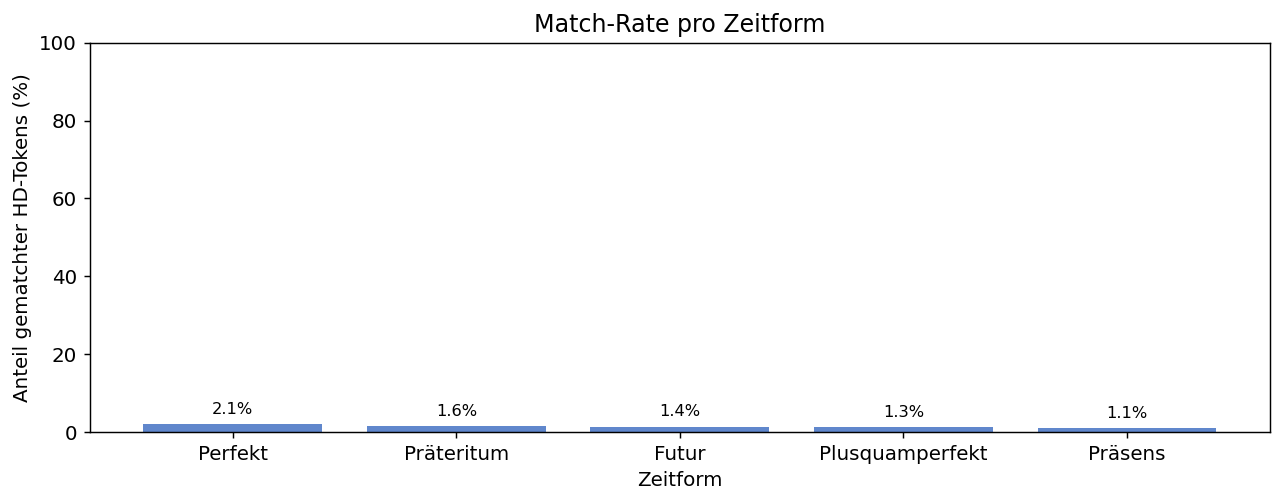

                 matched  total  match_pct
tense                                     
Perfekt               25   1198   2.086811
Präteritum            54   3373   1.600949
Futur                 37   2590   1.428571
Plusquamperfekt        3    231   1.298701
Präsens              191  17470   1.093303


In [4]:
df_ost["hd_token_count"] = df_ost["sentence"].apply(lambda x: len(tokenize_hd(x)))

# Remainder-Tokenzahl pro Satz
rem_counts = df_rem.set_index("sentence")["hd_remainder"].apply(
    lambda x: len(str(x).split(", "))
)
df_ost["hd_rem_count"] = df_ost["sentence"].map(rem_counts).fillna(0).astype(int)
df_ost["hd_matched_count"] = df_ost["hd_token_count"] - df_ost["hd_rem_count"]

tense_stats = df_ost.groupby("tense").agg(
    matched=("hd_matched_count", "sum"),
    total=("hd_token_count", "sum"),
).assign(match_pct=lambda d: d["matched"] / d["total"] * 100).sort_values("match_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(tense_stats.index, tense_stats["match_pct"], color="#4472C4", alpha=0.85)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_ylabel("Anteil gematchter HD-Tokens (%)")
ax.set_xlabel("Zeitform")
ax.set_title("Match-Rate pro Zeitform")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(tense_stats.to_string())

**Interpretation:** Zeitformen mit mehr Funktionswörtern (z.B. Perfekt: *hat*, *ist*) oder kürzeren Sätzen zeigen tendenziell höhere Match-Raten, da Funktionswörter im Korpus häufig genug auftreten, um die PMI-Schwelle zu überschreiten.

## 2. Wortmuster in `hd_remainder`

Welche HD-Wörter wurden am häufigsten nicht gematcht? Sind es eher Funktions- oder Inhaltswörter?

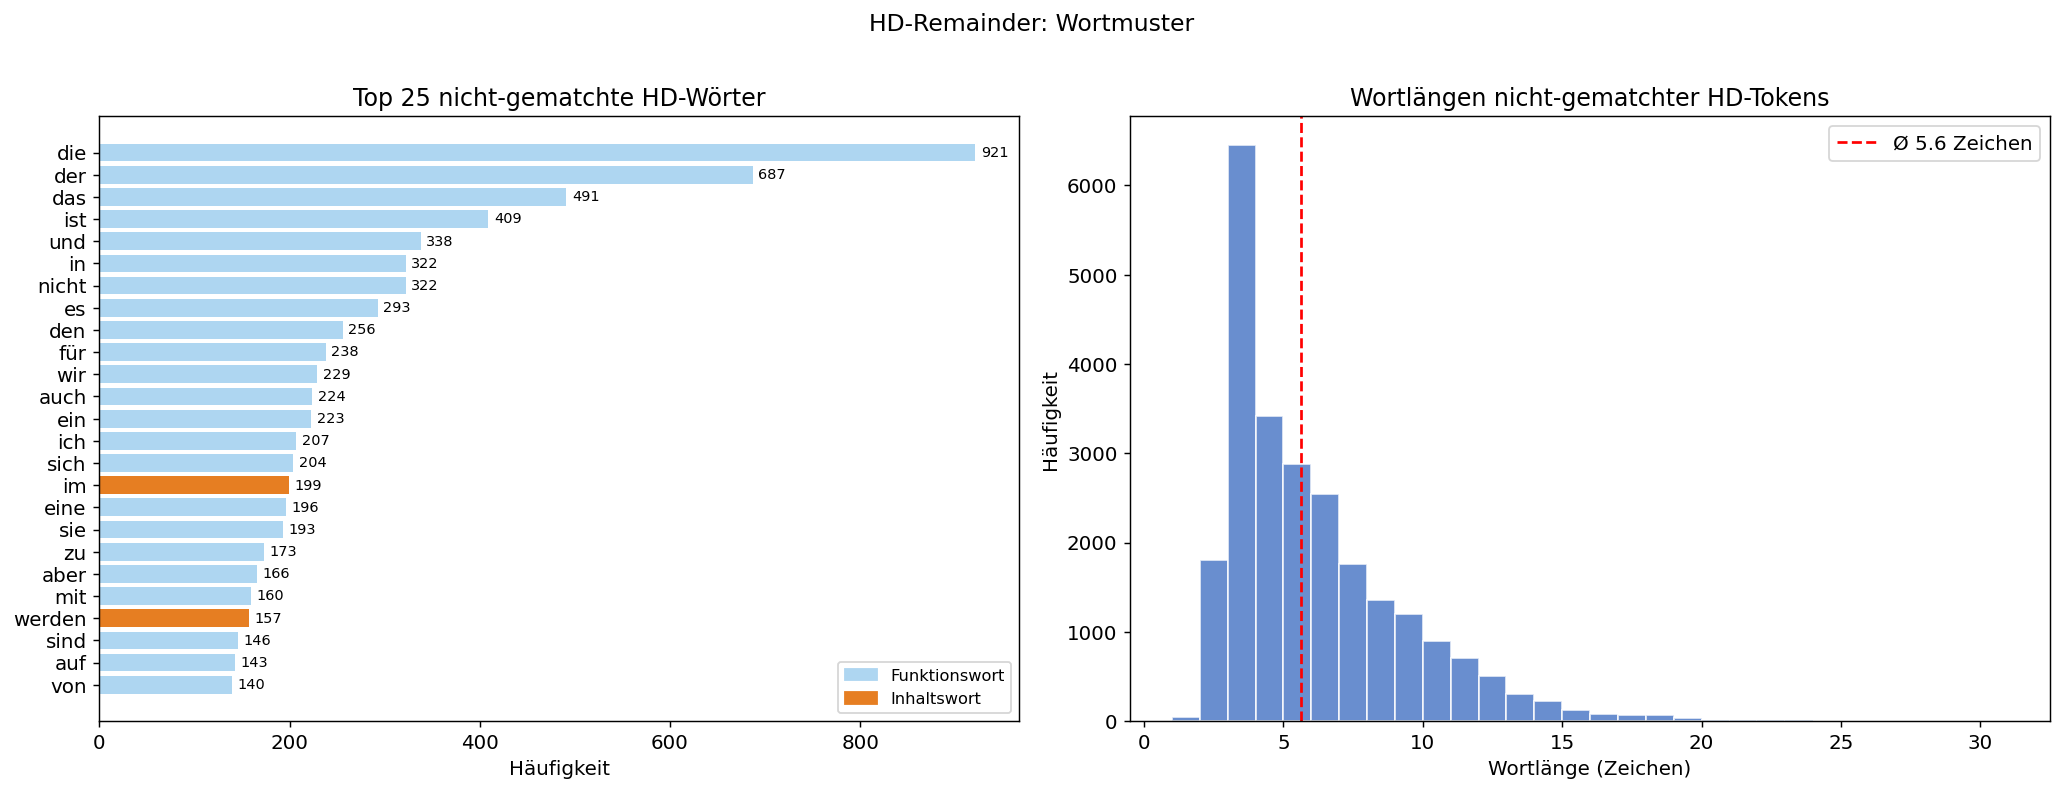

Remainder-Tokens total:   24,552
  davon Funktionswörter:  9,130  (37.2%)
  davon Inhaltswörter:    15,422  (62.8%)
Ø Wortlänge:              5.62 Zeichen


In [5]:
hd_rem_tokens = [
    tok
    for entry in df_rem["hd_remainder"].dropna()
    for tok in str(entry).split(", ")
    if tok
]
hd_rem_freq = Counter(hd_rem_tokens)

# Einfache Funktionswort-Liste (Deutsch)
STOPPWOERTER = {
    "der", "die", "das", "den", "dem", "des",
    "ein", "eine", "einen", "einem", "einer", "eines",
    "und", "oder", "aber", "doch", "weil", "dass", "ob",
    "ich", "du", "er", "sie", "es", "wir", "ihr",
    "mich", "dich", "sich", "uns", "euch",
    "in", "an", "auf", "aus", "bei", "mit", "nach", "seit",
    "von", "vor", "zu", "zwischen", "durch", "für", "gegen",
    "ist", "bin", "bist", "sind", "seid", "war", "waren",
    "hat", "habe", "haben", "hatte", "hatten",
    "nicht", "auch", "noch", "schon", "nur", "ja", "denn",
    "so", "wie", "als", "wenn", "dann", "da", "hier", "dort",
}

top_n = 25
top_hd = hd_rem_freq.most_common(top_n)
words, counts = zip(*top_hd)
colors = ["#AED6F1" if w in STOPPWOERTER else "#E67E22" for w in words]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Häufigste Remainder-Wörter
bars = axes[0].barh(words[::-1], counts[::-1], color=colors[::-1])
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_xlabel("Häufigkeit")
axes[0].set_title(f"Top {top_n} nicht-gematchte HD-Wörter")

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color="#AED6F1", label="Funktionswort"),
    Patch(color="#E67E22", label="Inhaltswort"),
], fontsize=9)

# Wortlängen-Verteilung
lengths = [len(t) for t in hd_rem_tokens]
axes[1].hist(lengths, bins=range(1, max(lengths) + 2), color="#4472C4", alpha=0.8, edgecolor="white")
axes[1].axvline(np.mean(lengths), color="red", linestyle="--", linewidth=1.5, label=f"Ø {np.mean(lengths):.1f} Zeichen")
axes[1].set_xlabel("Wortlänge (Zeichen)")
axes[1].set_ylabel("Häufigkeit")
axes[1].set_title("Wortlängen nicht-gematchter HD-Tokens")
axes[1].legend()

plt.suptitle("HD-Remainder: Wortmuster", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

n_stop = sum(1 for t in hd_rem_tokens if t in STOPPWOERTER)
print(f"Remainder-Tokens total:   {len(hd_rem_tokens):,}")
print(f"  davon Funktionswörter:  {n_stop:,}  ({n_stop/len(hd_rem_tokens)*100:.1f}%)")
print(f"  davon Inhaltswörter:    {len(hd_rem_tokens)-n_stop:,}  ({(len(hd_rem_tokens)-n_stop)/len(hd_rem_tokens)*100:.1f}%)")
print(f"Ø Wortlänge:              {np.mean(lengths):.2f} Zeichen")

**Interpretation:** Nicht-gematchte HD-Wörter sind überwiegend seltene Inhaltswörter (Nomen, Adjektive, seltene Verben), die im Korpus zu wenige Co-Occurrence-Treffer aufweisen. Funktionswörter, die trotzdem im Remainder sind, hatten wahrscheinlich zu niedrigen PMI (da sie in fast allen IPA-Sätzen vorkommen und damit unspezifisch sind).

## 3. IPA-Muster in `ipa_remainder`

Welche IPA-Tokens sind am häufigsten übrig geblieben?

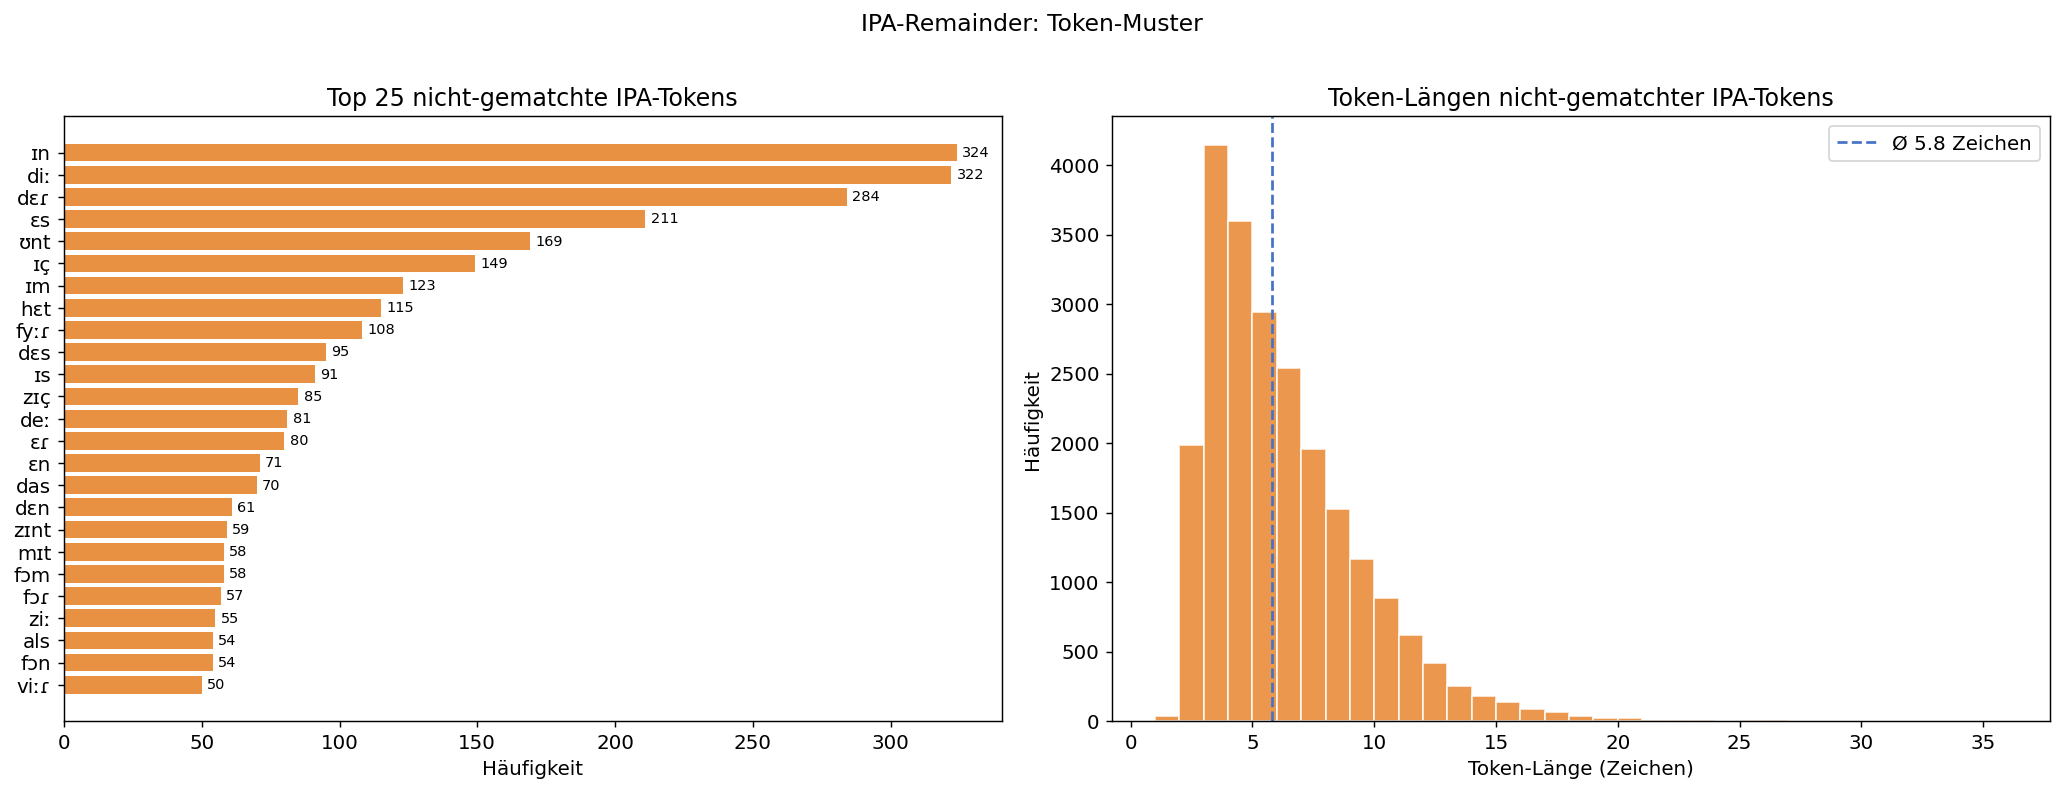

IPA-Remainder-Tokens total: 22,696
Einzigartige IPA-Types:     14,862
Ø Token-Länge:              5.79 Zeichen


In [6]:
ipa_rem_tokens = [
    tok
    for entry in df_rem["ipa_remainder"].dropna()
    for tok in str(entry).split(", ")
    if tok
]
ipa_rem_freq = Counter(ipa_rem_tokens)

top_ipa = ipa_rem_freq.most_common(25)
ipa_words, ipa_counts = zip(*top_ipa)
ipa_lengths = [len(t) for t in ipa_rem_tokens]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].barh(ipa_words[::-1], ipa_counts[::-1], color="#E67E22", alpha=0.85)
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_xlabel("Häufigkeit")
axes[0].set_title("Top 25 nicht-gematchte IPA-Tokens")

axes[1].hist(ipa_lengths, bins=range(1, max(ipa_lengths) + 2), color="#E67E22", alpha=0.8, edgecolor="white")
axes[1].axvline(np.mean(ipa_lengths), color="#4472C4", linestyle="--", linewidth=1.5, label=f"Ø {np.mean(ipa_lengths):.1f} Zeichen")
axes[1].set_xlabel("Token-Länge (Zeichen)")
axes[1].set_ylabel("Häufigkeit")
axes[1].set_title("Token-Längen nicht-gematchter IPA-Tokens")
axes[1].legend()

plt.suptitle("IPA-Remainder: Token-Muster", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"IPA-Remainder-Tokens total: {len(ipa_rem_tokens):,}")
print(f"Einzigartige IPA-Types:     {len(ipa_rem_freq):,}")
print(f"Ø Token-Länge:              {np.mean(ipa_lengths):.2f} Zeichen")

**Interpretation:** Häufige nicht-gematchte IPA-Tokens sind oft kurze Funktionswort-Entsprechungen oder Tokens, die zwar oft vorkommen, aber keinen eindeutigen HD-Partner haben (hohe IPA-Frequenz → niedriger PMI). Lange IPA-Tokens entsprechen meist seltenen, spezifischen Dialektwörtern.

## 4. Position im Satz

Stehen nicht-gematchte HD-Wörter eher am Anfang, in der Mitte oder am Ende des Satzes?
Relative Position: 0 = erstes Token, 1 = letztes Token.

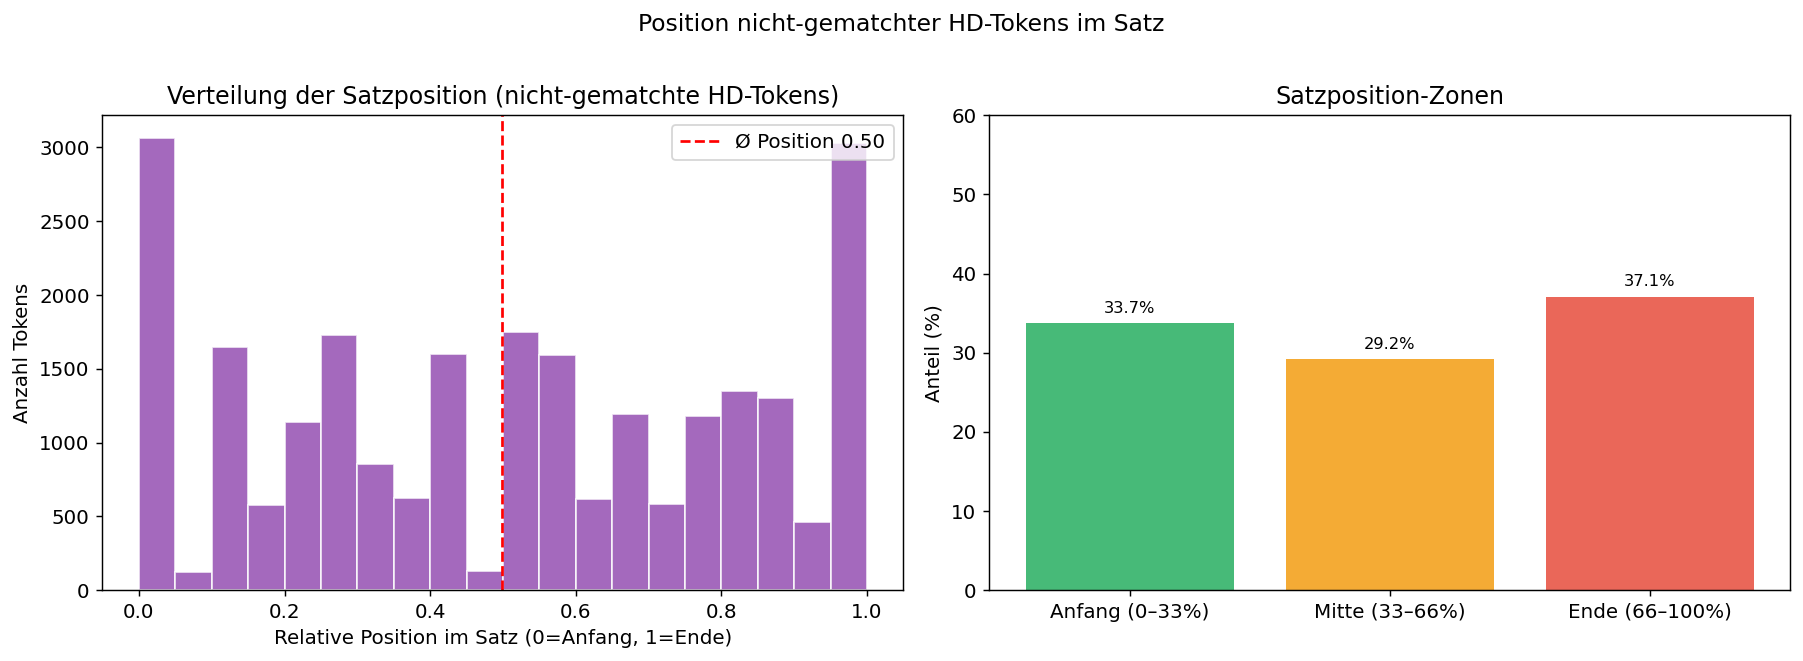

Analysierte Token-Positionen: 24,552
  Anfang (0–33%):  8283  (33.7%)
  Mitte (33–66%):  7166  (29.2%)
  Ende (66–100%):  9103  (37.1%)


In [7]:
positions = []
for _, row in df_rem.iterrows():
    original_tokens = tokenize_hd(row["sentence"])
    n = len(original_tokens)
    if n == 0:
        continue
    remainder_set = set(str(row["hd_remainder"]).split(", "))
    for i, tok in enumerate(original_tokens):
        if tok in remainder_set:
            positions.append(i / max(n - 1, 1))

# Drei Zonen: Anfang (0–0.33), Mitte (0.33–0.66), Ende (0.66–1.0)
zone_labels = ["Anfang (0–33%)", "Mitte (33–66%)", "Ende (66–100%)"]
zone_counts = [
    sum(1 for p in positions if p < 0.33),
    sum(1 for p in positions if 0.33 <= p < 0.66),
    sum(1 for p in positions if p >= 0.66),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm relative Position
axes[0].hist(positions, bins=20, color="#8E44AD", alpha=0.8, edgecolor="white")
axes[0].axvline(np.mean(positions), color="red", linestyle="--", linewidth=1.5,
                label=f"Ø Position {np.mean(positions):.2f}")
axes[0].set_xlabel("Relative Position im Satz (0=Anfang, 1=Ende)")
axes[0].set_ylabel("Anzahl Tokens")
axes[0].set_title("Verteilung der Satzposition (nicht-gematchte HD-Tokens)")
axes[0].legend()

# Zonenverteilung
zone_pct = [c / len(positions) * 100 for c in zone_counts]
bars = axes[1].bar(zone_labels, zone_pct, color=["#27AE60", "#F39C12", "#E74C3C"], alpha=0.85)
axes[1].bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
axes[1].set_ylabel("Anteil (%)")
axes[1].set_title("Satzposition-Zonen")
axes[1].set_ylim(0, 60)

plt.suptitle("Position nicht-gematchter HD-Tokens im Satz", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Analysierte Token-Positionen: {len(positions):,}")
for label, count, pct in zip(zone_labels, zone_counts, zone_pct):
    print(f"  {label}: {count:>5}  ({pct:.1f}%)")

**Interpretation:** Eine gleichmässige Verteilung deutet darauf hin, dass das Alignment keine systematische Positionsbias hat. Eine Häufung am Satzanfang oder -ende würde auf strukturelle Schwächen hinweisen (z.B. Subjekte oder Verbletztstellung im Dialekt werden schlechter erfasst).